##Importing Libraries

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import scipy
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

## Data Loading

In [5]:
DATA_DIR = "/content/"

CHAPTERS = {
    "02": "Common Mental Disorders (CMD)",
    "04": "PTSD",
    "05": "Psychotic Disorder",
    "07": "Personality Disorder",
    "08": "ADHD",
    "09": "Bipolar Disorder",
    "10": "Alcohol Use",
    "11": "Drug Dependence",
    "12": "Suicidal Behaviour",
}

REGIONS = [
    "North East", "North West", "Yorkshire & the Humber",
    "East Midlands", "West Midlands", "East of England",
    "London", "South East", "South West"
]

REGION_POPULATION = {
    "North East": 2154854, "North West": 5790512,
    "Yorkshire & the Humber": 4347165, "East Midlands": 3782353,
    "West Midlands": 4599064, "East of England": 4875281,
    "London": 6806412,  "South East": 7184102, "South West": 4473319,
}
ENGLAND_POPULATION = sum(REGION_POPULATION.values())


missing = []
for ch in CHAPTERS:
    path = os.path.join(DATA_DIR, f"apms-2014-ch-{ch}-tabs.xls")
    if not os.path.exists(path):
        missing.append(path)

if missing:
    print("WARNING — files not found:")
    for m in missing:
        print(f"  {m}")
else:
    print(f"All {len(CHAPTERS)} chapter files found in: {DATA_DIR}")
    for ch, name in CHAPTERS.items():
        path = os.path.join(DATA_DIR, f"apms-2014-ch-{ch}-tabs.xls")
        print(f"  ch-{ch}: {name}")

All 9 chapter files found in: /content/
  ch-02: Common Mental Disorders (CMD)
  ch-04: PTSD
  ch-05: Psychotic Disorder
  ch-07: Personality Disorder
  ch-08: ADHD
  ch-09: Bipolar Disorder
  ch-10: Alcohol Use
  ch-11: Drug Dependence
  ch-12: Suicidal Behaviour


## File Structures


In [11]:
print(f"{'Chapter':<10} {'Disorder':<35} {'Sheets'}")
print("-" * 90)
for ch, name in CHAPTERS.items():
    path = os.path.join(DATA_DIR, f"apms-2014-ch-{ch}-tabs.xls")
    xl = pd.ExcelFile(path)
    sheets = [s for s in xl.sheet_names if s not in ["Title sheet", "Table specifications ", "Table specification", "Corrections"]]
    print(f"  ch-{ch}  {name:<35} {sheets}")

Chapter    Disorder                            Sheets
------------------------------------------------------------------------------------------
  ch-02  Common Mental Disorders (CMD)       ['2.1', '2.2', '2.3', '2.4', '2.5', '2.6 ', '2.7', '2.8', '2.9 ', '2.10', '2.11', '2.12']
  ch-04  PTSD                                ['4.1', ' 4.2', '4.3', '4.4', '4.5', '4.6', '4.7', '4.8', '4.9', '4.10', '4.11', '4.12', '4.13']
  ch-05  Psychotic Disorder                  ['5.1', '5.2', '5.3', '5.4', '5.5', '5.6', '5.7', '5.8', '5.9', '5.10', '5.11', '5.12']
  ch-07  Personality Disorder                ['7.1', '7.2', '7.3', '7.4', '7.5', '7.6', '7.7', '7.8', '7.9', '7.10', '7.11', '7.12', '7.13', '7.14', '7.15', '7.16', '7.17', '7.18', '7.19', '7.20', '7.21']
  ch-08  ADHD                                ['8.1', '8.2', '8.3 ', '8.4', '8.5', '8.6', '8.7', '8.8', '8.9', '8.10', '8.11', '8.12']
  ch-09  Bipolar Disorder                    ['9.1', '9.2', '9.3', '9.4', '9.5', '9.6', ' 9.7', '9.8', '9.

In [12]:
path_ch02 = os.path.join(DATA_DIR, "apms-2014-ch-02-tabs.xls")
raw = pd.read_excel(path_ch02, sheet_name="2.11", header=None)

print("RAW Table 2.11 — first 35 rows (as stored in the XLS):")
print("=" * 80)
print(raw.iloc[:35, :].to_string())
print()
print(f"Full table shape: {raw.shape[0]} rows x {raw.shape[1]} columns")
print()
print("STRUCTURE EXPLANATION:")
print("  Row 0    : Table title")
print("  Row 3    : Region column headers (North East ... South West)")
print("  Row 4    : '%' unit markers")
print("  Row 5    : 'Observed' section header")
print("  Row 6    : 'Men' sub-header")
print("  Rows 7-13: Disorder-level percentages for Men")
print("  Row 15   : 'Women' sub-header")
print("  Rows 16-22: Disorder-level percentages for Women")
print("  Row 24   : 'All adults' sub-header")
print("  Rows 25-31: Disorder-level percentages for All adults")
print("  Rows 33-61: Same structure for Age-standardised values")
print("  Rows 63-66: BASE SIZES (sample n per region per sex)")

RAW Table 2.11 — first 35 rows (as stored in the XLS):
                                                                                   0           1           2                       3              4              5                6       7           8            9
0   Table 2.11  CMD in past week (observed and age-standardised), by region and sex          NaN         NaN                     NaN            NaN            NaN              NaN     NaN         NaN          NaN
1                                                                         All adults         NaN         NaN                     NaN            NaN           2014              NaN     NaN         NaN          NaN
2                                                                                NaN     Regiona         NaN                     NaN            NaN            NaN              NaN     NaN         NaN          NaN
3                                                                               CMDb  North E

## Confidence Interval



In [13]:
def wilson_ci(prevalence_pct, n, confidence=0.95):
    if pd.isna(prevalence_pct) or pd.isna(n) or n <= 0 or prevalence_pct < 0:
        return np.nan, np.nan, np.nan

    p = prevalence_pct / 100.0          # convert % to proportion
    z = stats.norm.ppf(1 - (1 - confidence) / 2)   # z = 1.96 for 95%

    denominator = 1 + z**2 / n
    centre      = (p + z**2 / (2 * n)) / denominator
    margin      = (z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denominator

    lower = max(0.0, (centre - margin) * 100)
    upper = min(100.0, (centre + margin) * 100)
    se    = (upper - lower) / (2 * z)          # standard error from CI width

    return round(lower, 4), round(upper, 4), round(se, 4)

p_test, n_test = 16.2, 395
lo, hi, se = wilson_ci(p_test, n_test)

print("Wilson Score CI — verification test")
print(f"  Disorder : Any CMD (North East, All Adults)")
print(f"  Prevalence: {p_test}%    Sample n: {n_test}")
print(f"  95% CI   : [{lo}% , {hi}%]")
print(f"  CI Width : {hi - lo:.4f} percentage points")
print(f"  SE       : ±{se:.4f}%")
print()
print("Interpretation: We are 95% confident the true prevalence of Any CMD")
print(f"in North East lies between {lo}% and {hi}%.")

Wilson Score CI — verification test
  Disorder : Any CMD (North East, All Adults)
  Prevalence: 16.2%    Sample n: 395
  95% CI   : [12.8949% , 20.1562%]
  CI Width : 7.2613 percentage points
  SE       : ±1.8524%

Interpretation: We are 95% confident the true prevalence of Any CMD
in North East lies between 12.8949% and 20.1562%.


## Extracting Data from Each Chapter



### Common Mental Disorders (CMD) - Table 2.11


In [14]:
def extract_ch02_cmd():
    path = os.path.join(DATA_DIR, "apms-2014-ch-02-tabs.xls")
    df = pd.read_excel(path, sheet_name="2.11", header=None)

    DISORDERS = [
        "Generalised anxiety disorder",
        "Depressive episode",
        "All phobias",
        "Obsessive compulsive disorder",
        "Panic disorder",
        "CMD - NOSb",
        "Any CMD",
    ]


    sex_obs_rows  = {"Men": 6,  "Women": 15, "All adults": 24}
    sex_std_rows  = {"Men": 36, "Women": 45, "All adults": 54}
    base_rows     = {"Men": 64, "Women": 65, "All adults": 66}

    records = []

    for sex, start_row in sex_obs_rows.items():
        base_vals = df.iloc[base_rows[sex], 1:10].values
        bases = {reg: float(base_vals[i]) if pd.notna(base_vals[i]) else np.nan
                 for i, reg in enumerate(REGIONS)}

        for offset, disorder in enumerate(DISORDERS):
            row_obs = df.iloc[start_row + 1 + offset, 1:10].values
            row_std = df.iloc[sex_std_rows[sex] + 1 + offset, 1:10].values

            for i, reg in enumerate(REGIONS):
                def safe(v):
                    try:
                        v2 = str(v).strip()
                        return np.nan if v2 in ['-','nan','NaN',''] else float(v2)
                    except:
                        return np.nan

                p_obs = safe(row_obs[i])
                p_std = safe(row_std[i])
                n     = bases.get(reg, np.nan)
                lo, hi, se = wilson_ci(p_obs, n)

                records.append({
                    "Chapter": "02",
                    "Disorder_Group": "Common Mental Disorders",
                    "Disorder": disorder.rstrip('b'),
                    "Sex": sex,
                    "Region": reg,
                    "Prevalence_Observed_%": p_obs,
                    "Prevalence_AgeStd_%": p_std,
                    "Sample_n": n,
                    "CI_Lower_95_%": lo,
                    "CI_Upper_95_%": hi,
                    "CI_Width_pp": round(hi - lo, 4) if not (np.isnan(hi) or np.isnan(lo)) else np.nan,
                    "SE_%": se,
                    "Source_Table": "2.11",
                })

    return pd.DataFrame(records)

cmd_df = extract_ch02_cmd()
print(f"CMD data extracted: {len(cmd_df)} rows")
print()


any_cmd = cmd_df[(cmd_df["Disorder"] == "Any CMD") & (cmd_df["Sex"] == "All adults")]
print("ANY CMD — All Adults — Observed Prevalence with 95% Confidence Intervals")
print("=" * 85)
display_cols = ["Region","Prevalence_Observed_%","Sample_n","CI_Lower_95_%","CI_Upper_95_%","CI_Width_pp"]
print(any_cmd[display_cols].to_string(index=False))

CMD data extracted: 189 rows

ANY CMD — All Adults — Observed Prevalence with 95% Confidence Intervals
                Region  Prevalence_Observed_%  Sample_n  CI_Lower_95_%  CI_Upper_95_%  CI_Width_pp
            North East                   16.2     395.0        12.8949        20.1562       7.2613
            North West                   19.0    1011.0        16.7009        21.5338       4.8329
Yorkshire & the Humber                   16.2     697.0        13.6511        19.1194       5.4683
         East Midlands                   16.7     723.0        14.1588        19.5932       5.4344
         West Midlands                   18.6     867.0        16.1505        21.3265       5.1760
       East of England                   14.1     852.0        11.9240        16.5983       4.6743
                London                   18.9     864.0        16.4293        21.6461       5.2168
            South East                   13.6    1289.0        11.8365        15.5798       3.7433
      

###PTSD - Table 4.6

In [16]:
def extract_ch04_ptsd():
    path = os.path.join(DATA_DIR, "apms-2014-ch-04-tabs.xls")
    df = pd.read_excel(path, sheet_name="4.6", header=None)

    indicators = ["Trauma experienced", "PTSD screen positive"]
    obs_rows   = {"Men": (7, 8), "Women": (11, 12), "All adults": (15, 16)}
    std_rows   = {"Men": (20, 21), "Women": (24, 25), "All adults": (28, 29)}
    base_rows  = {"Men": 32, "Women": 33, "All adults": 34}

    records = []
    for sex, (r_trauma, r_ptsd) in obs_rows.items():
        base_vals = df.iloc[base_rows[sex], 1:10].values
        bases = {reg: float(base_vals[i]) if pd.notna(base_vals[i]) else np.nan
                 for i, reg in enumerate(REGIONS)}

        for ind, row_obs_idx in zip(indicators, [r_trauma, r_ptsd]):
            row_obs = df.iloc[row_obs_idx, 1:10].values
            std_idx = std_rows[sex][0] if ind == "Trauma experienced" else std_rows[sex][1]
            row_std = df.iloc[std_idx, 1:10].values

            for i, reg in enumerate(REGIONS):
                def safe(v):
                    try:
                        v2 = str(v).strip()
                        return np.nan if v2 in ['-','nan','NaN',''] else float(v2)
                    except:
                        return np.nan
                p_obs = safe(row_obs[i])
                p_std = safe(row_std[i])
                n     = bases.get(reg, np.nan)
                lo, hi, se = wilson_ci(p_obs, n)
                records.append({
                    "Chapter": "04", "Disorder_Group": "PTSD",
                    "Disorder": ind, "Sex": sex, "Region": reg,
                    "Prevalence_Observed_%": p_obs, "Prevalence_AgeStd_%": p_std,
                    "Sample_n": n,
                    "CI_Lower_95_%": lo, "CI_Upper_95_%": hi,
                    "CI_Width_pp": round(hi-lo, 4) if not (np.isnan(hi) or np.isnan(lo)) else np.nan,
                    "SE_%": se, "Source_Table": "4.6",
                })
    return pd.DataFrame(records)

ptsd_df = extract_ch04_ptsd()
print(f"PTSD data extracted: {len(ptsd_df)} rows")
ptsd_all = ptsd_df[(ptsd_df["Disorder"] == "PTSD screen positive") & (ptsd_df["Sex"] == "All adults")]
print()
print("PTSD SCREEN POSITIVE — All Adults — 95% Confidence Intervals")
print("=" * 85)
print(ptsd_all[["Region","Prevalence_Observed_%","Sample_n","CI_Lower_95_%","CI_Upper_95_%","CI_Width_pp"]].to_string(index=False))

PTSD data extracted: 54 rows

PTSD SCREEN POSITIVE — All Adults — 95% Confidence Intervals
                Region  Prevalence_Observed_%  Sample_n  CI_Lower_95_%  CI_Upper_95_%  CI_Width_pp
            North East               3.686230     350.0         2.1624         6.2157       4.0533
            North West               4.672702     938.0         3.4971         6.2181       2.7210
Yorkshire & the Humber               4.875373     600.0         3.4210         6.9039       3.4829
         East Midlands               4.777852     662.0         3.3978         6.6797       3.2819
         West Midlands               4.648486     772.0         3.3747         6.3714       2.9967
       East of England               5.325483     808.0         3.9779         7.0958       3.1179
                London               4.486106     754.0         3.2251         6.2085       2.9834
            South East               3.296160    1185.0         2.4210         4.4731       2.0521
            South 

### Chapters 5, 7, 8, 9 - Psychosis, Personality Disorder, ADHD, Bipolar

In [17]:
def extract_ch05_psychosis():
    path = os.path.join(DATA_DIR, "apms-2014-ch-05-tabs.xls")
    df = pd.read_excel(path, sheet_name="5.5", header=None)

    sex_rows  = {"Men": 5, "Women": 6, "All adults": 7}
    base_rows = {"Men": 10, "Women": 11, "All adults": 12}
    records = []
    for sex, r in sex_rows.items():
        base_vals = df.iloc[base_rows[sex], 1:10].values
        bases = {reg: float(base_vals[i]) if pd.notna(base_vals[i]) else np.nan
                 for i, reg in enumerate(REGIONS)}
        row_obs = df.iloc[r, 1:10].values
        for i, reg in enumerate(REGIONS):
            def safe(v):
                try:
                    v2 = str(v).strip()
                    return np.nan if v2 in ['-','nan','NaN',''] else float(v2)
                except: return np.nan
            p = safe(row_obs[i]);  n = bases.get(reg, np.nan)
            lo, hi, se = wilson_ci(p, n)
            records.append({"Chapter":"05","Disorder_Group":"Psychotic Disorder",
                "Disorder":"Psychotic disorder (past year)","Sex":sex,"Region":reg,
                "Prevalence_Observed_%":p,"Prevalence_AgeStd_%":p,
                "Sample_n":n,"CI_Lower_95_%":lo,"CI_Upper_95_%":hi,
                "CI_Width_pp":round(hi-lo,4) if not (np.isnan(hi) or np.isnan(lo)) else np.nan,
                "SE_%":se,"Source_Table":"5.5"})
    return pd.DataFrame(records)

def extract_ch07_pd():
    path = os.path.join(DATA_DIR, "apms-2014-ch-07-tabs.xls")
    df = pd.read_excel(path, sheet_name="7.14", header=None)
    # Row 6=Men, 7=Women, 8=All (Observed)  |  Row 11=Men,12=Women,13=All (Age-std)
    # Bases: row 16 Men, 17 Women, 18 All
    obs_rows  = {"Men":6, "Women":7, "All adults":8}
    std_rows  = {"Men":11,"Women":12,"All adults":13}
    base_rows = {"Men":16,"Women":17,"All adults":18}
    records = []
    for sex, r_obs in obs_rows.items():
        base_vals = df.iloc[base_rows[sex], 1:10].values
        bases = {reg: float(base_vals[i]) if pd.notna(base_vals[i]) else np.nan
                 for i, reg in enumerate(REGIONS)}
        row_obs = df.iloc[r_obs, 1:10].values
        row_std = df.iloc[std_rows[sex], 1:10].values
        for i, reg in enumerate(REGIONS):
            def safe(v):
                try:
                    v2 = str(v).strip()
                    return np.nan if v2 in ['-','nan','NaN',''] else float(v2)
                except: return np.nan
            p_obs = safe(row_obs[i]); p_std = safe(row_std[i]); n = bases.get(reg, np.nan)
            lo, hi, se = wilson_ci(p_obs, n)
            records.append({"Chapter":"07","Disorder_Group":"Personality Disorder",
                "Disorder":"Any personality disorder (SAPAS)","Sex":sex,"Region":reg,
                "Prevalence_Observed_%":p_obs,"Prevalence_AgeStd_%":p_std,
                "Sample_n":n,"CI_Lower_95_%":lo,"CI_Upper_95_%":hi,
                "CI_Width_pp":round(hi-lo,4) if not (np.isnan(hi) or np.isnan(lo)) else np.nan,
                "SE_%":se,"Source_Table":"7.14"})
    return pd.DataFrame(records)

def extract_ch08_adhd():
    path = os.path.join(DATA_DIR, "apms-2014-ch-08-tabs.xls")
    df = pd.read_excel(path, sheet_name="8.6", header=None)
    # Men obs: rows 7 (4+), 8 (All 6)  |  Women obs: 11,12  |  All: 15,16
    # Bases: row 32 Men, 33 Women, 34 All
    indicators = ["ADHD screen (4+ symptoms)", "ADHD screen (all 6 symptoms)"]
    obs_rows  = {"Men":(7,8),"Women":(11,12),"All adults":(15,16)}
    std_rows  = {"Men":(20,21),"Women":(24,25),"All adults":(28,29)}
    base_rows = {"Men":32,"Women":33,"All adults":34}
    records = []
    for sex, (r1, r2) in obs_rows.items():
        base_vals = df.iloc[base_rows[sex], 1:10].values
        bases = {reg: float(base_vals[i]) if pd.notna(base_vals[i]) else np.nan
                 for i, reg in enumerate(REGIONS)}
        for ind, r_obs, r_std in zip(indicators, [r1,r2], list(std_rows[sex])):
            row_obs = df.iloc[r_obs, 1:10].values
            row_std = df.iloc[r_std, 1:10].values
            for i, reg in enumerate(REGIONS):
                def safe(v):
                    try:
                        v2 = str(v).strip()
                        return np.nan if v2 in ['-','nan','NaN',''] else float(v2)
                    except: return np.nan
                p_obs = safe(row_obs[i]); p_std = safe(row_std[i]); n = bases.get(reg, np.nan)
                lo, hi, se = wilson_ci(p_obs, n)
                records.append({"Chapter":"08","Disorder_Group":"ADHD",
                    "Disorder":ind,"Sex":sex,"Region":reg,
                    "Prevalence_Observed_%":p_obs,"Prevalence_AgeStd_%":p_std,
                    "Sample_n":n,"CI_Lower_95_%":lo,"CI_Upper_95_%":hi,
                    "CI_Width_pp":round(hi-lo,4) if not (np.isnan(hi) or np.isnan(lo)) else np.nan,
                    "SE_%":se,"Source_Table":"8.6"})
    return pd.DataFrame(records)

def extract_ch09_bipolar():
    path = os.path.join(DATA_DIR, "apms-2014-ch-09-tabs.xls")
    df = pd.read_excel(path, sheet_name="9.4", header=None)
    # Rows 6=Men,7=Women,8=All (Obs)  |  11,12,13 (Std)  |  Bases 16,17,18
    obs_rows  = {"Men":6,"Women":7,"All adults":8}
    std_rows  = {"Men":11,"Women":12,"All adults":13}
    base_rows = {"Men":16,"Women":17,"All adults":18}
    records = []
    for sex, r_obs in obs_rows.items():
        base_vals = df.iloc[base_rows[sex], 1:10].values
        bases = {reg: float(base_vals[i]) if pd.notna(base_vals[i]) else np.nan
                 for i, reg in enumerate(REGIONS)}
        row_obs = df.iloc[r_obs, 1:10].values
        row_std = df.iloc[std_rows[sex], 1:10].values
        for i, reg in enumerate(REGIONS):
            def safe(v):
                try:
                    v2 = str(v).strip()
                    return np.nan if v2 in ['-','nan','NaN',''] else float(v2)
                except: return np.nan
            p_obs = safe(row_obs[i]); p_std = safe(row_std[i]); n = bases.get(reg, np.nan)
            lo, hi, se = wilson_ci(p_obs, n)
            records.append({"Chapter":"09","Disorder_Group":"Bipolar Disorder",
                "Disorder":"Bipolar disorder screen positive","Sex":sex,"Region":reg,
                "Prevalence_Observed_%":p_obs,"Prevalence_AgeStd_%":p_std,
                "Sample_n":n,"CI_Lower_95_%":lo,"CI_Upper_95_%":hi,
                "CI_Width_pp":round(hi-lo,4) if not (np.isnan(hi) or np.isnan(lo)) else np.nan,
                "SE_%":se,"Source_Table":"9.4"})
    return pd.DataFrame(records)

psych_df  = extract_ch05_psychosis()
pd_df     = extract_ch07_pd()
adhd_df   = extract_ch08_adhd()
bipolar_df = extract_ch09_bipolar()

print(f"Psychosis rows : {len(psych_df)}")
print(f"PD rows        : {len(pd_df)}")
print(f"ADHD rows      : {len(adhd_df)}")
print(f"Bipolar rows   : {len(bipolar_df)}")

Psychosis rows : 27
PD rows        : 27
ADHD rows      : 54
Bipolar rows   : 27


### Chapters 10, 11, 12 — Alcohol, Drug Dependence, Suicidal Behaviour

In [18]:
def extract_ch10_alcohol():
    path = os.path.join(DATA_DIR, "apms-2014-ch-10-tabs.xls")
    df = pd.read_excel(path, sheet_name="10.6", header=None)

    indicators = [
        "Non-drinker/low risk (AUDIT 0-7)",
        "Hazardous drinking (AUDIT 8-15)",
        "Harmful/mild dependence (AUDIT 16-19)",
        "Probable dependence (AUDIT 20+)",
        "Harmful/dependent drinking (AUDIT 8+)",
        "High-risk drinking (AUDIT 16+)",
    ]
    obs_start = {"Men":6,"Women":15,"All adults":24}
    base_rows  = {"Men":None,"Women":None,"All adults":None}


    ch02 = pd.read_excel(os.path.join(DATA_DIR, "apms-2014-ch-02-tabs.xls"), sheet_name="2.11", header=None)
    base_proxy = {
        "Men":       {reg: float(ch02.iloc[64, i+1]) for i, reg in enumerate(REGIONS)},
        "Women":     {reg: float(ch02.iloc[65, i+1]) for i, reg in enumerate(REGIONS)},
        "All adults":{reg: float(ch02.iloc[66, i+1]) for i, reg in enumerate(REGIONS)},
    }

    records = []
    for sex, start in obs_start.items():
        bases = base_proxy[sex]
        for offset, ind in enumerate(indicators):
            row_obs = df.iloc[start + 1 + (offset if offset < 4 else offset+1), 1:10].values
            for i, reg in enumerate(REGIONS):
                def safe(v):
                    try:
                        v2 = str(v).strip()
                        return np.nan if v2 in ['-','nan','NaN',''] else float(v2)
                    except: return np.nan
                p = safe(row_obs[i]); n = bases.get(reg, np.nan)
                lo, hi, se = wilson_ci(p, n)
                records.append({"Chapter":"10","Disorder_Group":"Alcohol Use",
                    "Disorder":ind,"Sex":sex,"Region":reg,
                    "Prevalence_Observed_%":p,"Prevalence_AgeStd_%":p,
                    "Sample_n":n,"CI_Lower_95_%":lo,"CI_Upper_95_%":hi,
                    "CI_Width_pp":round(hi-lo,4) if not (np.isnan(hi) or np.isnan(lo)) else np.nan,
                    "SE_%":se,"Source_Table":"10.6"})
    return pd.DataFrame(records)

def extract_ch11_drug():
    path = os.path.join(DATA_DIR, "apms-2014-ch-11-tabs.xls")
    df = pd.read_excel(path, sheet_name="11.11", header=None)

    indicators = ["Cannabis only dependence","Other drug(s) dependence","Any drug dependence"]
    sex_rows  = {"Men":(6,7,8),"Women":(11,12,13),"All adults":(16,17,18)}
    base_rows = {"Men":21,"Women":22,"All adults":23}
    records = []
    for sex, rows in sex_rows.items():
        base_vals = df.iloc[base_rows[sex], 1:10].values
        bases = {reg: float(base_vals[i]) if pd.notna(base_vals[i]) else np.nan
                 for i, reg in enumerate(REGIONS)}
        for ind, r in zip(indicators, rows):
            row_obs = df.iloc[r, 1:10].values
            for i, reg in enumerate(REGIONS):
                def safe(v):
                    try:
                        v2 = str(v).strip()
                        return np.nan if v2 in ['-','nan','NaN',''] else float(v2)
                    except: return np.nan
                p = safe(row_obs[i]); n = bases.get(reg, np.nan)
                lo, hi, se = wilson_ci(p, n)
                records.append({"Chapter":"11","Disorder_Group":"Drug Dependence",
                    "Disorder":ind,"Sex":sex,"Region":reg,
                    "Prevalence_Observed_%":p,"Prevalence_AgeStd_%":p,
                    "Sample_n":n,"CI_Lower_95_%":lo,"CI_Upper_95_%":hi,
                    "CI_Width_pp":round(hi-lo,4) if not (np.isnan(hi) or np.isnan(lo)) else np.nan,
                    "SE_%":se,"Source_Table":"11.11"})
    return pd.DataFrame(records)

def extract_ch12_suicide():
    path = os.path.join(DATA_DIR, "apms-2014-ch-12-tabs.xls")
    df = pd.read_excel(path, sheet_name="12.7", header=None)

    indicators = ["Lifetime suicidal thoughts","Lifetime suicide attempts","Lifetime self-harm"]
    sex_rows  = {"Men":(7,8,9),"Women":(11,12,13),"All adults":(15,16,17)}
    std_rows  = {"Men":(21,22,23),"Women":(25,26,27),"All adults":(29,30,31)}
    base_rows = {"Men":34,"Women":35,"All adults":36}
    records = []
    for sex, rows in sex_rows.items():
        base_vals = df.iloc[base_rows[sex], 1:10].values
        bases = {reg: float(base_vals[i]) if pd.notna(base_vals[i]) else np.nan
                 for i, reg in enumerate(REGIONS)}
        for ind, r_obs, r_std in zip(indicators, rows, std_rows[sex]):
            row_obs = df.iloc[r_obs, 1:10].values
            row_std = df.iloc[r_std, 1:10].values
            for i, reg in enumerate(REGIONS):
                def safe(v):
                    try:
                        v2 = str(v).strip()
                        return np.nan if v2 in ['-','nan','NaN',''] else float(v2)
                    except: return np.nan
                p_obs = safe(row_obs[i]); p_std = safe(row_std[i]); n = bases.get(reg, np.nan)
                lo, hi, se = wilson_ci(p_obs, n)
                records.append({"Chapter":"12","Disorder_Group":"Suicidal Behaviour",
                    "Disorder":ind,"Sex":sex,"Region":reg,
                    "Prevalence_Observed_%":p_obs,"Prevalence_AgeStd_%":p_std,
                    "Sample_n":n,"CI_Lower_95_%":lo,"CI_Upper_95_%":hi,
                    "CI_Width_pp":round(hi-lo,4) if not (np.isnan(hi) or np.isnan(lo)) else np.nan,
                    "SE_%":se,"Source_Table":"12.7"})
    return pd.DataFrame(records)

alcohol_df = extract_ch10_alcohol()
drug_df    = extract_ch11_drug()
suicide_df = extract_ch12_suicide()

print(f"Alcohol rows : {len(alcohol_df)}")
print(f"Drug rows    : {len(drug_df)}")
print(f"Suicide rows : {len(suicide_df)}")

Alcohol rows : 162
Drug rows    : 81
Suicide rows : 81


## Combining all Data into One Master DataFrame

In [19]:
master_df = pd.concat(
    [cmd_df, ptsd_df, psych_df, pd_df, adhd_df, bipolar_df, alcohol_df, drug_df, suicide_df],
    ignore_index=True
)

master_df["Region_Population"] = master_df["Region"].map(REGION_POPULATION)
master_df["England_Population"] = ENGLAND_POPULATION
master_df["Population_Weight"]  = master_df["Region_Population"] / ENGLAND_POPULATION


col_order = [
    "Chapter","Disorder_Group","Disorder","Sex","Region",
    "Prevalence_Observed_%","Prevalence_AgeStd_%",
    "Sample_n","CI_Lower_95_%","CI_Upper_95_%","CI_Width_pp","SE_%",
    "Region_Population","Population_Weight","Source_Table"
]
master_df = master_df[col_order]

print(f"MASTER DATASET SUMMARY")
print(f"{'='*60}")
print(f"Total rows     : {len(master_df):,}")
print(f"Disorder groups: {master_df['Disorder_Group'].nunique()}")
print(f"Disorders      : {master_df['Disorder'].nunique()}")
print(f"Regions        : {master_df['Region'].nunique()}")
print(f"Sex categories : {master_df['Sex'].unique()}")
print()
print("Rows per Disorder Group:")
print(master_df.groupby("Disorder_Group").size().to_string())
print()
print("Sample of master_df:")
print(master_df.head(10).to_string(index=False))

MASTER DATASET SUMMARY
Total rows     : 702
Disorder groups: 9
Disorders      : 26
Regions        : 9
Sex categories : ['Men' 'Women' 'All adults']

Rows per Disorder Group:
Disorder_Group
ADHD                        54
Alcohol Use                162
Bipolar Disorder            27
Common Mental Disorders    189
Drug Dependence             81
PTSD                        54
Personality Disorder        27
Psychotic Disorder          27
Suicidal Behaviour          81

Sample of master_df:
Chapter          Disorder_Group                     Disorder Sex                 Region  Prevalence_Observed_%  Prevalence_AgeStd_%  Sample_n  CI_Lower_95_%  CI_Upper_95_%  CI_Width_pp   SE_%  Region_Population  Population_Weight Source_Table
     02 Common Mental Disorders Generalised anxiety disorder Men             North East                    5.7                  5.3     155.0         3.0101        10.5326       7.5225 1.9190            2154854           0.048959         2.11
     02 Common Mental Di

## Descriptive Statistics


In [20]:
all_adults = master_df[master_df["Sex"] == "All adults"].copy()

print("DESCRIPTIVE STATISTICS — All Adults, Observed Prevalence")
print("=" * 95)
stats_df = (
    all_adults
    .groupby(["Disorder_Group","Disorder"])["Prevalence_Observed_%"]
    .agg(
        N_regions="count",
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Min="min",
        Max="max",
        Range=lambda x: x.max() - x.min(),
        CV_pct=lambda x: (x.std() / x.mean() * 100) if x.mean() != 0 else np.nan
    )
    .round(3)
    .reset_index()
)
print(stats_df.to_string(index=False))
print()
print("CV% = Coefficient of Variation — higher means more regional variation")

DESCRIPTIVE STATISTICS — All Adults, Observed Prevalence
         Disorder_Group                              Disorder  N_regions   Mean  Median  Std_Dev    Min    Max  Range  CV_pct
                   ADHD             ADHD screen (4+ symptoms)          9  9.627   9.931    1.336  7.521 11.685  4.164  13.875
                   ADHD          ADHD screen (all 6 symptoms)          9  0.650   0.645    0.313  0.358  1.403  1.045  48.136
            Alcohol Use Harmful/dependent drinking (AUDIT 8+)          9 19.762  18.765    3.121 15.531 25.497  9.966  15.791
            Alcohol Use Harmful/mild dependence (AUDIT 16-19)          9  1.857   1.780    0.564  0.691  2.575  1.884  30.381
            Alcohol Use       Hazardous drinking (AUDIT 8-15)          9 16.633  15.190    3.047 12.739 22.373  9.633  18.321
            Alcohol Use        High-risk drinking (AUDIT 16+)          9  3.129   3.124    0.616  2.128  4.117  1.988  19.684
            Alcohol Use      Non-drinker/low risk (AUDIT 0-7)

## Regional CI Table for Key Disorders



In [21]:
key_disorders = [
    ("Common Mental Disorders", "Any CMD"),
    ("PTSD",                    "PTSD screen positive"),
    ("Psychotic Disorder",      "Psychotic disorder (past year)"),
    ("Personality Disorder",    "Any personality disorder (SAPAS)"),
    ("Bipolar Disorder",        "Bipolar disorder screen positive"),
    ("Drug Dependence",         "Any drug dependence"),
]

SEP = "-" * 88

for grp, dis in key_disorders:
    sub = all_adults[(all_adults["Disorder_Group"] == grp) & (all_adults["Disorder"] == dis)].copy()
    if sub.empty:
        continue

    valid = sub.dropna(subset=["Prevalence_Observed_%"])
    eng_avg = (valid["Prevalence_Observed_%"] * valid["Population_Weight"]).sum() / valid["Population_Weight"].sum()
    eng_n   = int(valid["Sample_n"].sum())
    eng_lo, eng_hi, eng_se = wilson_ci(eng_avg, eng_n)

    print(SEP)
    print("  " + dis.upper() + " -- " + grp)
    print(SEP)
    print("  {:<30} {:>12} {:>7} {:>13} {:>13} {:>10} {:>7}".format(
        "Region","Prevalence%","n","95% CI Lower","95% CI Upper","CI Width","SE%"))
    print("  " + "-"*28 + " " + "-"*12 + " " + "-"*7 + " " + "-"*13 + " " + "-"*13 + " " + "-"*10 + " " + "-"*7)

    for _, row in sub.iterrows():
        flag = " *" if (not pd.isna(row["CI_Lower_95_%"]) and
                        (row["Prevalence_Observed_%"] == valid["Prevalence_Observed_%"].max() or
                         row["Prevalence_Observed_%"] == valid["Prevalence_Observed_%"].min())) else "  "
        ci_lo = row["CI_Lower_95_%"] if not pd.isna(row["CI_Lower_95_%"]) else 0
        ci_hi = row["CI_Upper_95_%"] if not pd.isna(row["CI_Upper_95_%"]) else 0
        ci_w  = row["CI_Width_pp"]   if not pd.isna(row["CI_Width_pp"])   else 0
        se    = row["SE_%"]           if not pd.isna(row["SE_%"])           else 0
        n_val = int(row["Sample_n"]) if not pd.isna(row["Sample_n"]) else 0
        print("  {:<30} {:>11.3f}% {:>7} {:>12.3f}% {:>12.3f}% {:>9.3f}pp {:>6.3f}%{}".format(
            row["Region"], row["Prevalence_Observed_%"], n_val, ci_lo, ci_hi, ci_w, se, flag))

    print("  " + "-"*28 + " " + "-"*12 + " " + "-"*7 + " " + "-"*13 + " " + "-"*13 + " " + "-"*10 + " " + "-"*7)
    print("  {:<30} {:>11.3f}% {:>7} {:>12.3f}% {:>12.3f}% {:>9.3f}pp {:>6.3f}%".format(
        "ENGLAND (weighted avg)", eng_avg, eng_n, eng_lo, eng_hi, eng_hi-eng_lo, eng_se))
    print("  (* = highest or lowest region)")
    print()

----------------------------------------------------------------------------------------
  ANY CMD -- Common Mental Disorders
----------------------------------------------------------------------------------------
  Region                          Prevalence%       n  95% CI Lower  95% CI Upper   CI Width     SE%
  ---------------------------- ------------ ------- ------------- ------------- ---------- -------
  North East                          16.200%     395       12.895%       20.156%     7.261pp  1.852%  
  North West                          19.000%    1011       16.701%       21.534%     4.833pp  1.233%  
  Yorkshire & the Humber              16.200%     697       13.651%       19.119%     5.468pp  1.395%  
  East Midlands                       16.700%     723       14.159%       19.593%     5.434pp  1.386%  
  West Midlands                       18.600%     867       16.151%       21.326%     5.176pp  1.321%  
  East of England                     14.100%     852       11.92

## Composite Mental Health Burden Score


In [22]:
key_combos = [
    ("Common Mental Disorders","Any CMD"),
    ("PTSD","PTSD screen positive"),
    ("Psychotic Disorder","Psychotic disorder (past year)"),
    ("Personality Disorder","Any personality disorder (SAPAS)"),
    ("ADHD","ADHD screen (4+ symptoms)"),
    ("Bipolar Disorder","Bipolar disorder screen positive"),
    ("Alcohol Use","High-risk drinking (AUDIT 16+)"),
    ("Drug Dependence","Any drug dependence"),
    ("Suicidal Behaviour","Lifetime suicidal thoughts"),
]

disorder_labels = [d for _, d in key_combos]
grp_labels      = [g for g, _ in key_combos]

sub_all = all_adults[
    all_adults.apply(lambda r: (r["Disorder_Group"], r["Disorder"]) in key_combos, axis=1)
].copy()

matrix = sub_all.pivot_table(
    index="Region", columns="Disorder", values="Prevalence_Observed_%"
)
z_matrix = (matrix - matrix.mean()) / matrix.std()

composite = z_matrix.mean(axis=1).sort_values(ascending=False).round(4)
composite_df = composite.reset_index()
composite_df.columns = ["Region","Composite_Z_Score"]
composite_df["Burden_Category"] = composite_df["Composite_Z_Score"].apply(
    lambda z: "High" if z > 0.3 else ("Above average" if z > 0 else ("Below average" if z > -0.3 else "Low"))
)
composite_df["Region_Population"] = composite_df["Region"].map(REGION_POPULATION)

print("COMPOSITE MENTAL HEALTH BURDEN SCORE BY REGION")
print("(Higher score = more disorders above England average)")
print("=" * 72)
print("{:<6} {:<32} {:>10} {:<18} {:>12}".format("Rank","Region","Z-Score","Category","Population"))
print("-" * 72)
for rank, (_, row) in enumerate(composite_df.iterrows(), 1):
    sign = "+" if row["Composite_Z_Score"] >= 0 else ""
    bar = ">" * min(10, int(abs(row["Composite_Z_Score"]) * 10))
    print("  {:<4} {:<32} {:}{:>8.4f}   {:<18} {:>12,}  {}".format(
        rank, row["Region"], sign, row["Composite_Z_Score"],
        row["Burden_Category"], int(row["Region_Population"]), bar))
print()
print("Z-score: 0 = England average. +1 = 1 std dev above average.")

COMPOSITE MENTAL HEALTH BURDEN SCORE BY REGION
(Higher score = more disorders above England average)
Rank   Region                              Z-Score Category             Population
------------------------------------------------------------------------
  1    London                           +  0.7826   High                  6,806,412  >>>>>>>
  2    East of England                  +  0.6133   High                  4,875,281  >>>>>>
  3    East Midlands                    +  0.3553   High                  3,782,353  >>>
  4    West Midlands                    +  0.1726   Above average         4,599,064  >
  5    North West                       +  0.0994   Above average         5,790,512  
  6    Yorkshire & the Humber            -0.0198   Below average         4,347,165  
  7    South West                        -0.2792   Below average         4,473,319  >>
  8    North East                        -0.6064   Low                   2,154,854  >>>>>>
  9    South East                

##Visualisations

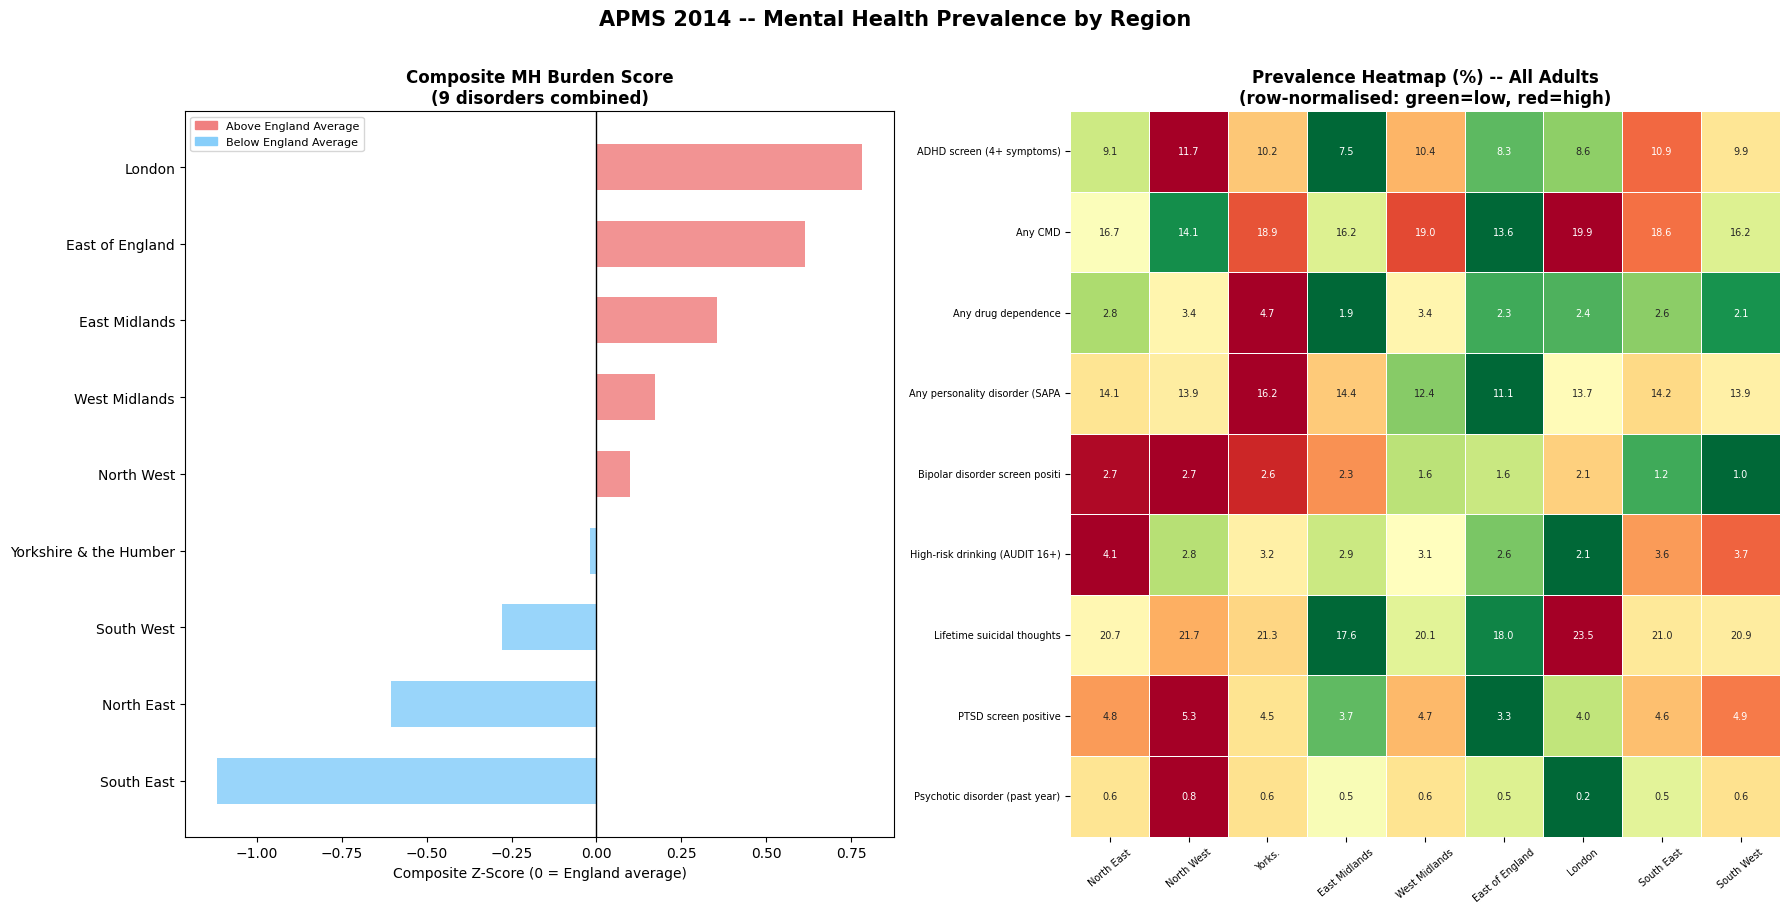

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.suptitle("APMS 2014 -- Mental Health Prevalence by Region", fontsize=15, fontweight="bold", y=1.01)


# Plot 1: Composite burden score
ax2 = axes[0]
comp_sorted = composite_df.sort_values("Composite_Z_Score", ascending=True)
colors2 = ["lightcoral" if z > 0 else "lightskyblue" for z in comp_sorted["Composite_Z_Score"]]
bars2 = ax2.barh(comp_sorted["Region"], comp_sorted["Composite_Z_Score"], color=colors2, alpha=0.85, height=0.6)
ax2.axvline(0, color="black", linewidth=1)
ax2.set_xlabel("Composite Z-Score (0 = England average)")
ax2.set_title("Composite MH Burden Score\n(9 disorders combined)", fontweight="bold")
patches = [mpatches.Patch(color="lightcoral", label="Above England Average"),
           mpatches.Patch(color="lightskyblue", label="Below England Average")]
ax2.legend(handles=patches, fontsize=8)

# Plot 2: Heatmap
ax3 = axes[1]
heat_disorders = ["Any CMD","PTSD screen positive","Psychotic disorder (past year)",
                  "Any personality disorder (SAPAS)","ADHD screen (4+ symptoms)",
                  "Bipolar disorder screen positive","High-risk drinking (AUDIT 16+)",
                  "Any drug dependence","Lifetime suicidal thoughts"]
heat_data = all_adults[all_adults["Disorder"].isin(heat_disorders)].pivot_table(
    index="Disorder", columns="Region", values="Prevalence_Observed_%"
)
heat_data.index = [d[:30] for d in heat_data.index]
heat_norm = heat_data.apply(lambda row: (row - row.min())/(row.max() - row.min()) if row.max()>row.min() else row, axis=1)
region_short = [r.replace("Yorkshire & the Humber","Yorks.") for r in REGIONS]
sns.heatmap(heat_norm, ax=ax3, cmap="RdYlGn_r", annot=heat_data.round(1),
            fmt=".1f", annot_kws={"size":7}, linewidths=0.5, cbar=False,
            xticklabels=region_short)
ax3.set_title("Prevalence Heatmap (%) -- All Adults\n(row-normalised: green=low, red=high)", fontweight="bold")
ax3.tick_params(axis="x", rotation=40, labelsize=7)
ax3.tick_params(axis="y", rotation=0, labelsize=7)
ax3.set_xlabel(""); ax3.set_ylabel("")

plt.tight_layout()
plt.show()

## National Summary Table (England Weighted Averages)

In [35]:
summary_rows = []
for grp, dis in key_combos:
    sub = all_adults[(all_adults["Disorder_Group"]==grp)&(all_adults["Disorder"]==dis)].dropna(subset=["Prevalence_Observed_%"])
    if sub.empty: continue
    eng_avg = (sub["Prevalence_Observed_%"] * sub["Population_Weight"]).sum() / sub["Population_Weight"].sum()
    eng_n   = int(sub["Sample_n"].sum())
    lo, hi, se = wilson_ci(eng_avg, eng_n)
    min_reg = sub.loc[sub["Prevalence_Observed_%"].idxmin(), "Region"]
    max_reg = sub.loc[sub["Prevalence_Observed_%"].idxmax(), "Region"]
    summary_rows.append({
        "Disorder_Group": grp,
        "Disorder": dis,
        "England_Avg_%": round(eng_avg, 3),
        "Total_n": eng_n,
        "CI_Lower_%": lo,
        "CI_Upper_%": hi,
        "CI_Width_pp": round(hi-lo, 3),
        "Lowest_Region": f"{min_reg} ({sub['Prevalence_Observed_%'].min():.2f}%)",
        "Highest_Region": f"{max_reg} ({sub['Prevalence_Observed_%'].max():.2f}%)",
        "Range_pp": round(sub["Prevalence_Observed_%"].max() - sub["Prevalence_Observed_%"].min(), 3),
    })

summary_df = pd.DataFrame(summary_rows)
print("ENGLAND NATIONAL SUMMARY — Weighted Prevalence Estimates with 95% CI")
print("=" * 120)
print(summary_df.to_string(index=False))

ENGLAND NATIONAL SUMMARY — Weighted Prevalence Estimates with 95% CI
         Disorder_Group                         Disorder  England_Avg_%  Total_n  CI_Lower_%  CI_Upper_%  CI_Width_pp                  Lowest_Region           Highest_Region  Range_pp
Common Mental Disorders                          Any CMD         16.999     7546     16.1681     17.8630        1.695            South East (13.60%)      South West (19.90%)     6.300
                   PTSD             PTSD screen positive          4.403     6843      3.9418      4.9151        0.973             South East (3.30%)  East of England (5.33%)     2.029
     Psychotic Disorder   Psychotic disorder (past year)          0.539    14579      0.4328      0.6720        0.239             South West (0.20%)  East of England (0.85%)     0.649
   Personality Disorder Any personality disorder (SAPAS)         13.667     7082     12.8870     14.4870        1.600            South East (11.14%)          London (16.18%)     5.034
           

## Export All Results in Excel

In [36]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.formatting.rule import ColorScaleRule
from openpyxl.utils import get_column_letter

OUTPUT_DIR = "/content/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

csv_path = os.path.join(OUTPUT_DIR, "APMS2014_MH_Regional_Model_MasterData.csv")
master_df.to_csv(csv_path, index=False)
print(f"CSV exported  : {csv_path}  ({len(master_df):,} rows)")

xlsx_path = os.path.join(OUTPUT_DIR, "APMS2014_MH_Regional_Statistical_Model.xlsx")

def hdr(bold=True, color="FFFFFFFF", size=10):
    return Font(name="Calibri", bold=bold, color=color, size=size)
def fill(hex_c):
    return PatternFill("solid", fgColor=hex_c)
def thin_border():
    s = Side(style="thin", color="FFBFBFBF")
    return Border(left=s, right=s, top=s, bottom=s)
def ctr():
    return Alignment(horizontal="center", vertical="center", wrap_text=True)
def lft():
    return Alignment(horizontal="left", vertical="center", wrap_text=True)

DARK = "FF1F3864"; MED = "FF2E5FA3"; LIGHT = "FFD6E4F7"

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:

    # Sheet 1: Master data
    master_df.to_excel(writer, sheet_name="All Data", index=False)
    ws = writer.sheets["All Data"]
    for col_idx, col in enumerate(master_df.columns, 1):
        c = ws.cell(row=1, column=col_idx)
        c.font = hdr(); c.fill = fill(DARK); c.alignment = ctr(); c.border = thin_border()
    ws.auto_filter.ref = ws.dimensions
    ws.freeze_panes = "A2"

    # Sheet 2: National summary
    summary_df.to_excel(writer, sheet_name="England Summary", index=False)
    ws2 = writer.sheets["England Summary"]
    for col_idx in range(1, len(summary_df.columns)+1):
        c = ws2.cell(row=1, column=col_idx)
        c.font = hdr(); c.fill = fill(DARK); c.alignment = ctr(); c.border = thin_border()
    for row in range(2, len(summary_df)+2):
        for col_idx in range(1, len(summary_df.columns)+1):
            c = ws2.cell(row=row, column=col_idx)
            c.border = thin_border()
            c.fill = fill("FFF2F6FC") if row % 2 == 0 else fill("FFFFFFFF")
    ws2.freeze_panes = "A2"

    # Sheet 3: Composite scores
    composite_df.to_excel(writer, sheet_name="Composite Burden Score", index=False)
    ws3 = writer.sheets["Composite Burden Score"]
    for col_idx in range(1, len(composite_df.columns)+1):
        c = ws3.cell(row=1, column=col_idx)
        c.font = hdr(); c.fill = fill(DARK); c.alignment = ctr(); c.border = thin_border()
    for row in range(2, len(composite_df)+2):
        for col_idx in range(1, len(composite_df.columns)+1):
            c = ws3.cell(row=row, column=col_idx)
            c.border = thin_border()
    ws3.freeze_panes = "A2"

    # Sheet 4: Pivot — Any CMD by region with CI
    any_cmd_full = all_adults[all_adults["Disorder"]=="Any CMD"][
        ["Region","Prevalence_Observed_%","Prevalence_AgeStd_%","Sample_n",
         "CI_Lower_95_%","CI_Upper_95_%","CI_Width_pp","SE_%","Population_Weight"]
    ].copy().reset_index(drop=True)
    any_cmd_full.to_excel(writer, sheet_name="CMD by Region (CI)", index=False)
    ws4 = writer.sheets["CMD by Region (CI)"]
    for col_idx in range(1, len(any_cmd_full.columns)+1):
        c = ws4.cell(row=1, column=col_idx)
        c.font = hdr(); c.fill = fill(MED); c.alignment = ctr(); c.border = thin_border()
    ws4.auto_filter.ref = ws4.dimensions

    # Sheet 5: Descriptive statistics
    stats_df.to_excel(writer, sheet_name="Descriptive Statistics", index=False)
    ws5 = writer.sheets["Descriptive Statistics"]
    for col_idx in range(1, len(stats_df.columns)+1):
        c = ws5.cell(row=1, column=col_idx)
        c.font = hdr(); c.fill = fill(DARK); c.alignment = ctr(); c.border = thin_border()
    ws5.auto_filter.ref = ws5.dimensions

print(f"Excel exported: {xlsx_path}")
print()
print("EXPORT SUMMARY")
print("=" * 55)
print(f"  Master CSV   : {len(master_df):,} rows × {len(master_df.columns)} columns")
print(f"  Excel sheets : All Data | England Summary | Composite Burden Score | CMD by Region | Descriptive Statistics")
print(f"  Location     : {OUTPUT_DIR}")

CSV exported  : /content/APMS2014_MH_Regional_Model_MasterData.csv  (702 rows)
Excel exported: /content/APMS2014_MH_Regional_Statistical_Model.xlsx

EXPORT SUMMARY
  Master CSV   : 702 rows × 15 columns
  Excel sheets : All Data | England Summary | Composite Burden Score | CMD by Region | Descriptive Statistics
  Location     : /content/
